## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/mago_water_quality_monitoring_tool/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)


# MAGO Water Quality Monitoring Tool with OpenEO

This notebook converts the MAGO Water Quality Monitoring Tool to an openEO User-Defined Process. MAGO estimates a set of water-quality parameters in lakes, reservoirs, and large ponds from Sentinel-2 imagery. The user picks one of eight indicators at runtime via the `indicator` parameter and adjusts the color scale with `min_value` / `max_value`.

## Overview

1. Connect to an OpenEO backend.
2. Load Sentinel-2 L2A bands required by the eight MAGO indicators.
3. Mask non-water pixels with NDWI (true color fallback).
4. Compute the selected indicator and map it to a 5-stop Blue → Red color scale.
5. Export the result as a parameterized openEO process graph.

The tool was developed for Mediterranean inland waters by CETAQUA as part of the PRIMA MAGO project.


## Scientific Background

Water-quality retrievals from Sentinel-2 rely on the differential absorption and reflectance of sunlight by water constituents (chlorophyll-a, phycocyanin, suspended matter, colored dissolved organic matter).

The eight indicators in the MAGO tool:

| ID | Parameter | Formula | Range | Reference |
|----|-----------|---------|-------|-----------|
| 0 | Chlorophyll-a (NDCI based) | `14.039 + 86.11·NDCI + 194.325·NDCI²` with `NDCI=(B05−B04)/(B05+B04)` | 0.9–28.1 mg/m³ | Mishra & Mishra, 2012 |
| 1 | Chlorophyll-a (high values) | `19.866·(B05/B04)^2.3051` | 5.16–674.7 mg/m³ | Soria-Perpinyà et al., 2021 |
| 2 | Chlorophyll-a (low values) | `10^(−2.4792·log10(max(B03,B02)/B03) − 0.0389)` | 0.53–4.92 mg/m³ | Soria-Perpinyà et al., 2021 |
| 3 | Cyanobacteria (phycocyanin) cells/mL | `115530.31·((B03·B04)/B02²)^2.38` | 0.1–283 000 cells/mL | Potes et al., 2018 |
| 4 | Cyanobacteria (phycocyanin) mg/m³ | `21.554·(B05/B04)^3.4791` | 0.13–1040 mg/m³ | Soria-Perpinyà et al., 2021 |
| 5 | Turbidity (NTU) | `194.79·(B05·(B05/B02)) + 0.9061` | 15–1000 NTU | Zhan et al., 2022 |
| 6 | CDOM (µg/L) | `2.4072·(B04/B02) + 0.0709` | 0.03–5.30 µg/L | Soria-Perpinyà et al., 2021 |
| 7 | TSS (mg/L) | `14.464·(B07/B02) + 16.336` | 20–78.82 mg/L | Soria-Perpinyà et al., 2021 |

**Water mask:** MAGO uses a simple NDWI filter — pixels with `NDWI = (B03 − B08)/(B03 + B08) < 0` are displayed in true color (land).

**Color scale:** a 5-stop linear gradient (Blue → Cyan → Green → Yellow → Red) stretched between `min_value` and `max_value`. Adjust these to fit the value range of the selected indicator.


## Import Libraries


In [1]:
import json

import matplotlib.pyplot as plt
from PIL import Image
from openeo.api.process import Parameter
from openeo.processes import array_create, eq, if_, log, power, subtract
from openeo.processes import max as oe_max

from openeo_udp import ParameterManager

## Load Parameters and Connect to OpenEO Backend


In [2]:
param_manager = ParameterManager('mago_water_quality.params.py')
param_manager.print_options("MAGO Water Quality Monitoring Tool")

Available parameter sets for MAGO Water Quality Monitoring Tool:
  1. barrage_lebna: Barrage Lebna, Tunisia
  2. alqueva_reservoir: Alqueva Reservoir, Portugal
  3. albufera_valencia: L'Albufera de Valencia, Spain
  4. mar_menor_lagoon: Mar Menor Lagoon, Spain

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8081/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# selection_widget = param_manager.interactive_parameter_selection()

print("\nAlternative (programmatic):")
print("   connection, params = param_manager.quick_connect('barrage_lebna', 'eopf_explorer')")


Alternative (programmatic):
   connection, params = param_manager.quick_connect('barrage_lebna', 'eopf_explorer')


## Define UDP Runtime Parameters

These three parameters are exposed on the final UDP so the same graph can serve any of the eight indicators without recompiling.


In [4]:
indicator = Parameter.integer(
    "indicator",
    description=(
        "MAGO indicator to compute: "
        "0=Chl-a NDCI, 1=Chl-a high, 2=Chl-a low, "
        "3=Cyano cells/mL, 4=Cyano phycocyanin mg/m³, "
        "5=Turbidity NTU, 6=CDOM µg/L, 7=TSS mg/L"
    ),
    default=0,
)

min_value = Parameter.number(
    "min_value",
    description="Lower bound of the color scale (Blue)",
    default=6,
)

max_value = Parameter.number(
    "max_value",
    description="Upper bound of the color scale (Red)",
    default=12,
)

## Load Sentinel-2 Data

The six bands below cover all eight MAGO indicators:
- **B02** (490 nm): turbidity, CDOM, TSS denominators
- **B03** (560 nm): NDWI, low Chl-a, cyano cells
- **B04** (665 nm): NDCI red, cyano cells, CDOM numerator
- **B05** (705 nm): NDCI red-edge, high Chl-a, cyano phycocyanin, turbidity
- **B07** (783 nm): TSS
- **B08** (842 nm): NDWI (water detection)


In [5]:
# connection, current_params = selection_widget()
connection, current_params = param_manager.quick_connect('barrage_lebna', 'copernicus_dataspace')

s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"].default,
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: barrage_lebna
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Barrage Lebna, Tunisia
🔄 Parameters mapped for endpoint copernicus_dataspace:


## MAGO Visualization Function

The function below:
1. Computes all eight MAGO indicators from the band stack.
2. Selects one indicator using the `indicator` parameter.
3. Normalizes the value between `min_value` and `max_value`.
4. Maps it onto a 5-stop Blue → Cyan → Green → Yellow → Red gradient.
5. Falls back to true color where NDWI indicates non-water pixels.


In [ ]:
def mago_visualization(data, context):
    """Apply the MAGO Water Quality visualization.

    Input data array order: [B02, B03, B04, B05, B07, B08].
    Context array order:    [indicator, min_value, max_value].

    Top-level openEO Parameter references are not visible inside a callback's
    scope; they must be plumbed in via the `context` argument of
    apply_dimension. See openEO spec for `apply_dimension.context`.
    """
    B02, B03, B04, B05, B07, B08 = data[0], data[1], data[2], data[3], data[4], data[5]
    indicator = 0
    min_value = 6
    max_value = 12

    # Scale DN -> reflectance. Required because indicator 5 (turbidity) uses
    # B05^2/B02, which is not unit-free and was calibrated against [0, 1] reflectance.
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000
    B05 = B05 / 10000
    B07 = B07 / 10000
    B08 = B08 / 10000

    # Water mask (NDWI > 0 -> water)
    NDWI = (B03 - B08) / (B03 + B08)

    # --- Indicator formulas -------------------------------------------------
    # 0: Chl-a NDCI (Mishra 2012)
    ndci = (B05 - B04) / (B05 + B04)
    chl_ndci = 14.039 + 86.11 * ndci + 194.325 * power(ndci, 2)

    # 1: Chl-a high values (Soria-Perpinya 2021)
    chl_high = 19.866 * power(B05 / B04, 2.3051)

    # 2: Chl-a low values (Soria-Perpinya 2021)
    #    10^(-2.4792 * log10(max(B03,B02)/B03) - 0.0389)
    chl_low = power(
        10,
        -2.4792 * log(oe_max(B03, B02) / B03, base=10) - 0.0389,
    )

    # 3: Cyanobacteria phycocyanin cells/mL (Potes 2018)
    cyano_cells = 115530.31 * power((B03 * B04) / power(B02, 2), 2.38)

    # 4: Cyanobacteria phycocyanin mg/m^3 (Soria-Perpinya 2021)
    cyano_phyco = 21.554 * power(B05 / B04, 3.4791)

    # 5: Turbidity NTU (Zhan 2022)
    turbidity = 194.79 * (B05 * (B05 / B02)) + 0.9061

    # 6: CDOM microg/L (Soria-Perpinya 2021)
    cdom = 2.4072 * (B04 / B02) + 0.0709

    # 7: TSS mg/L (Soria-Perpinya 2021)
    tss = 14.464 * (B07 / B02) + 16.336

    # Pick the indicator corresponding to the context value.
    # Use eq(indicator, N) because `indicator == N` would evaluate in Python.
    value = if_(
        eq(indicator, 0), chl_ndci,
        if_(
            eq(indicator, 1), chl_high,
            if_(
                eq(indicator, 2), chl_low,
                if_(
                    eq(indicator, 3), cyano_cells,
                    if_(
                        eq(indicator, 4), cyano_phyco,
                        if_(
                            eq(indicator, 5), turbidity,
                            if_(eq(indicator, 6), cdom, tss),
                        ),
                    ),
                ),
            ),
        ),
    )

    # --- Color mapping ------------------------------------------------------
    # subtract() is needed because raw arithmetic between context-derived
    # ProcessBuilders may fail depending on the client version.
    span = subtract(max_value, min_value)
    t = (value - min_value) / span

    # Piecewise linear interpolation across 4 segments:
    #   [0.00, 0.25] Blue   (0, 0, 1) -> Cyan   (0, 1, 1)
    #   [0.25, 0.50] Cyan   (0, 1, 1) -> Green  (0, 1, 0)
    #   [0.50, 0.75] Green  (0, 1, 0) -> Yellow (1, 1, 0)
    #   [0.75, 1.00] Yellow (1, 1, 0) -> Red    (1, 0, 0)
    seg0 = (t - 0.00) * 4
    seg1 = (t - 0.25) * 4
    seg2 = (t - 0.50) * 4
    seg3 = (t - 0.75) * 4

    r = if_(t <= 0.5, 0, if_(t <= 0.75, seg2, 1))
    g = if_(t <= 0.25, seg0, if_(t <= 0.75, 1, 1 - seg3))
    b = if_(t <= 0.25, 1, if_(t <= 0.5, 1 - seg1, 0))

    # Clamp to Blue below 0 and Red above 1
    r = if_(t < 0, 0, if_(t > 1, 1, r))
    g = if_(t < 0, 0, if_(t > 1, 0, g))
    b = if_(t < 0, 1, if_(t > 1, 0, b))

    indicator_color = array_create([r, g, b])

    # True color fallback for non-water pixels (scale by 3 as in MAGO source)
    land_color = array_create([B04 * 3, B03 * 3, B02 * 3])

    return if_(NDWI < 0, land_color, indicator_color)

## Apply the Algorithm


In [13]:
# Synchronous preview — resolve Parameters to their defaults here because
# the backend rejects `from_parameter` references on a direct /result call.
# (The UDP export below keeps the Parameter references intact.)
mago_image = s2cube.apply_dimension(
    dimension="bands",
    process=mago_visualization,
    context=[0, 6, 12],
)
mago_image = mago_image.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

## Download and Visualize

Running the default (`indicator=0`, Chl-a NDCI, scale 0–30) on the selected location.


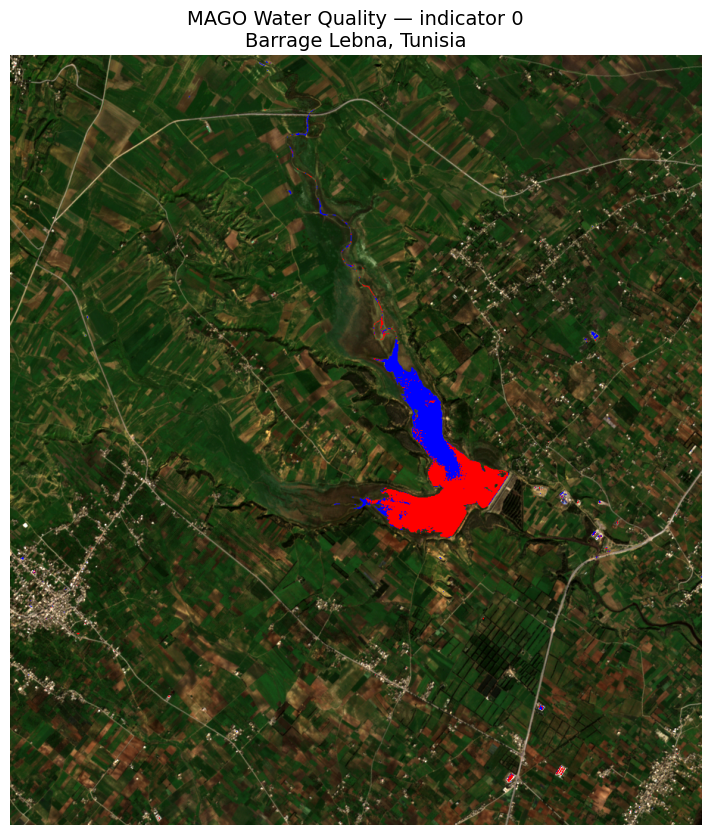

In [14]:
filename = f"mago_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

# Synchronous execution — no UDP parameter declarations needed; every
# `from_parameter` ref has been resolved to a concrete default above.
connection.download(
    {
        "process_graph": mago_image.save_result("PNG").flat_graph(),
        "parameters": [
            current_params["time"].to_dict(),
            current_params["bounding_box"].to_dict(),
            current_params["bands"].to_dict(),
            indicator.to_dict(),
            min_value.to_dict(),
            max_value.to_dict(),
        ],
    },
    filename,
)

img = Image.open(filename)
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.title(
    f"MAGO Water Quality — indicator {indicator.default}\n{current_params['location_name']}",
    fontsize=14,
)
plt.axis("off")
plt.show()

## Export Process Graph

The exported JSON is the parameterized UDP: `indicator`, `min_value`, `max_value`, plus the standard spatial / temporal / bands parameters.


In [9]:
# Build the parameterized UDP graph: context wraps actual Parameter
# references so the exported graph stays runtime-configurable.
udp_image = s2cube.apply_dimension(
    dimension="bands",
    process=mago_visualization,
    context=[indicator, min_value, max_value],
).linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

udp = {
    "id": "mago_water_quality",
    "summary": "MAGO Water Quality Monitoring Tool",
    "description": (
        "Estimates water quality parameters (chlorophyll-a, cyanobacteria, "
        "turbidity, CDOM, TSS) in inland water bodies from Sentinel-2 imagery. "
        "The indicator is selectable at runtime via the 'indicator' parameter "
        "(0–7). Color scale is controlled by 'min_value' and 'max_value'. "
        "Non-water pixels (NDWI < 0) are rendered in true color."
    ),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["bands"].to_dict(),
        indicator.to_dict(),
        min_value.to_dict(),
        max_value.to_dict(),
    ],
    "process_graph": udp_image.save_result("PNG").flat_graph(),
}

graph_path = "../../../../graphs/sentinel/sentinel-2/marine_and_water_bodies/mago_water_quality.json"
import os
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
with open(graph_path, "w") as f:
    json.dump(udp, f, indent=2)

print(f"Process graph exported to {graph_path}")
print(f"Process ID: {udp['id']}")

Process graph exported to ../../../../graphs/sentinel/sentinel-2/marine_and_water_bodies/mago_water_quality.json
Process ID: mago_water_quality


## Indicator Selection Guide

| Indicator | Suggested min / max | Notes |
|-----------|--------------------|-------|
| 0 – Chl-a NDCI | 0 / 30 | General chlorophyll-a retrieval (Mishra 2012) |
| 1 – Chl-a high | 5 / 675 | Use when blooms are expected |
| 2 – Chl-a low | 0.5 / 5 | Oligotrophic / clear-water lakes |
| 3 – Cyano cells/mL | 100 / 10 000 | Widely varying — adjust to local conditions |
| 4 – Cyano phycocyanin mg/m³ | 0 / 100 | Broader dynamic range than indicator 3 |
| 5 – Turbidity NTU | 15 / 300 | Developed for Mediterranean reservoirs |
| 6 – CDOM µg/L | 0 / 5 | Low dynamic range |
| 7 – TSS mg/L | 20 / 80 | Validated on a small sample (n=11) |

## Limitations

- Only the top ~50 cm of the water column contributes to the signal.
- Sen2Cor atmospheric correction is not optimal over water; expect outliers.
- Mixed constituents (e.g. turbid algal water) confound single-parameter retrievals.
- Most formulas were validated on Mediterranean inland waters — transfer with care.


## Attribution and References

**Original evalscript:** [MAGO Water Quality Monitoring Tool](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/mago_water_quality_monitoring_tool/)

**Developed by:** CETAQUA, within the PRIMA MAGO project (supported by the European Union).

**Source repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Mishra, S., Mishra, D.R., 2012. Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote Sens. Environ.* 117, 394–406. <https://doi.org/10.1016/j.rse.2011.10.016>
- Potes, M., Rodrigues, G., Marchã Penha, A., et al., 2018. Use of Sentinel 2-MSI for water quality monitoring at Alqueva reservoir, Portugal. *Proc. IAHS* 380, 73–79. <https://doi.org/10.5194/piahs-380-73-2018>
- Sòria-Perpinyà, X., Vicente, E., Urrego, P., et al., 2021. Validation of water quality monitoring algorithms for Sentinel-2 and Sentinel-3 in Mediterranean inland waters with in situ reflectance data. *Water* 13, 686. <https://doi.org/10.3390/w13050686>
- Zhan, Y., Delegido, J., Erena, M., et al., 2022. Mar Menor lagoon (SE Spain) chlorophyll-a and turbidity estimation with Sentinel-2. *Limnetica* 41, 1. <https://doi.org/10.23818/limn.41.18>

### License

CC-BY-SA 4.0. Please cite as: *MAGO Water Quality Monitoring Tool, open code for EO Browser developed within the PRIMA MAGO Project by CETAQUA*.
